# Anomaly Detection 

First step: three tree-based models are applied
1. Random Forest model
2. Gradient Boosting model (GBDT)
3. LightGBM model (an optimized version of Gradient Boosting)

To address the strong class imbalance problem, three different resampling strategies were used:

1. RandomUnderSampler: a method that reduces the majority class → may lead to loss of information
2. SMOTE: generates synthetic samples (interpolation between nearest neighbors) to increase the minority class
3. Class_weight: a Scikit-learn method that assigns higher penalties to the majority class via weighting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


## 1. Manually annotated target

In [3]:
df=pd.read_csv(r"/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/df_final.csv")
df.head()

,DateTime,Time,Error,WEC: ava. windspeed,WEC: max. windspeed,WEC: min. windspeed,WEC: ava. Rotation,WEC: max. Rotation,WEC: min. Rotation,WEC: ava. Power,...,Yaw inverter cabinet temp.,Fan inverter cabinet temp.,Ambient temp.,Tower temp.,Control cabinet temp.,Transformer temp.,RTU: ava. Setpoint 1,Inverter averages,Inverter std dev,target
0,2014-05-01 00:00:00,1398920448,0,6.9,9.4,2.9,0.0,0.02,0.0,0,...,20,25,12,14,24,34,2501,25.272728,1.103713,0
1,2014-05-01 00:09:00,1398920960,0,5.3,8.9,1.6,0.0,0.01,0.0,0,...,20,25,12,14,24,34,2501,25.272728,1.103713,0
2,2014-05-01 00:20:00,1398921600,0,5.0,9.5,1.4,0.0,0.04,0.0,0,...,20,25,12,14,24,34,2501,25.272728,1.103713,0
3,2014-05-01 00:30:00,1398922240,0,4.4,8.3,1.3,0.0,0.08,0.0,0,...,21,25,12,14,24,34,2501,25.272728,1.103713,0
4,2014-05-01 00:39:00,1398922752,0,5.7,9.7,1.2,0.0,0.05,0.0,0,...,21,25,12,14,23,34,2501,25.272728,1.103713,0


In [4]:
df['target'].value_counts()

target
0    47588
1      861
2      578
Name: count, dtype: int64

In [5]:
df.columns

Index(['DateTime', 'Time', 'Error', 'WEC: ava. windspeed',
       'WEC: max. windspeed', 'WEC: min. windspeed', 'WEC: ava. Rotation',
       'WEC: max. Rotation', 'WEC: min. Rotation', 'WEC: ava. Power',
       'WEC: max. Power', 'WEC: min. Power',
       'WEC: ava. Nacel position including cable twisting',
       'WEC: Operating Hours', 'WEC: Production kWh',
       'WEC: Production minutes', 'WEC: ava. reactive Power',
       'WEC: max. reactive Power', 'WEC: min. reactive Power',
       'WEC: ava. available P from wind',
       'WEC: ava. available P technical reasons',
       'WEC: ava. Available P force majeure reasons',
       'WEC: ava. Available P force external reasons',
       'WEC: ava. blade angle A', 'Sys 1 inverter 1 cabinet temp.',
       'Sys 1 inverter 2 cabinet temp.', 'Sys 1 inverter 3 cabinet temp.',
       'Sys 1 inverter 4 cabinet temp.', 'Sys 1 inverter 5 cabinet temp.',
       'Sys 1 inverter 6 cabinet temp.', 'Sys 1 inverter 7 cabinet temp.',
       'Sys 2 inve

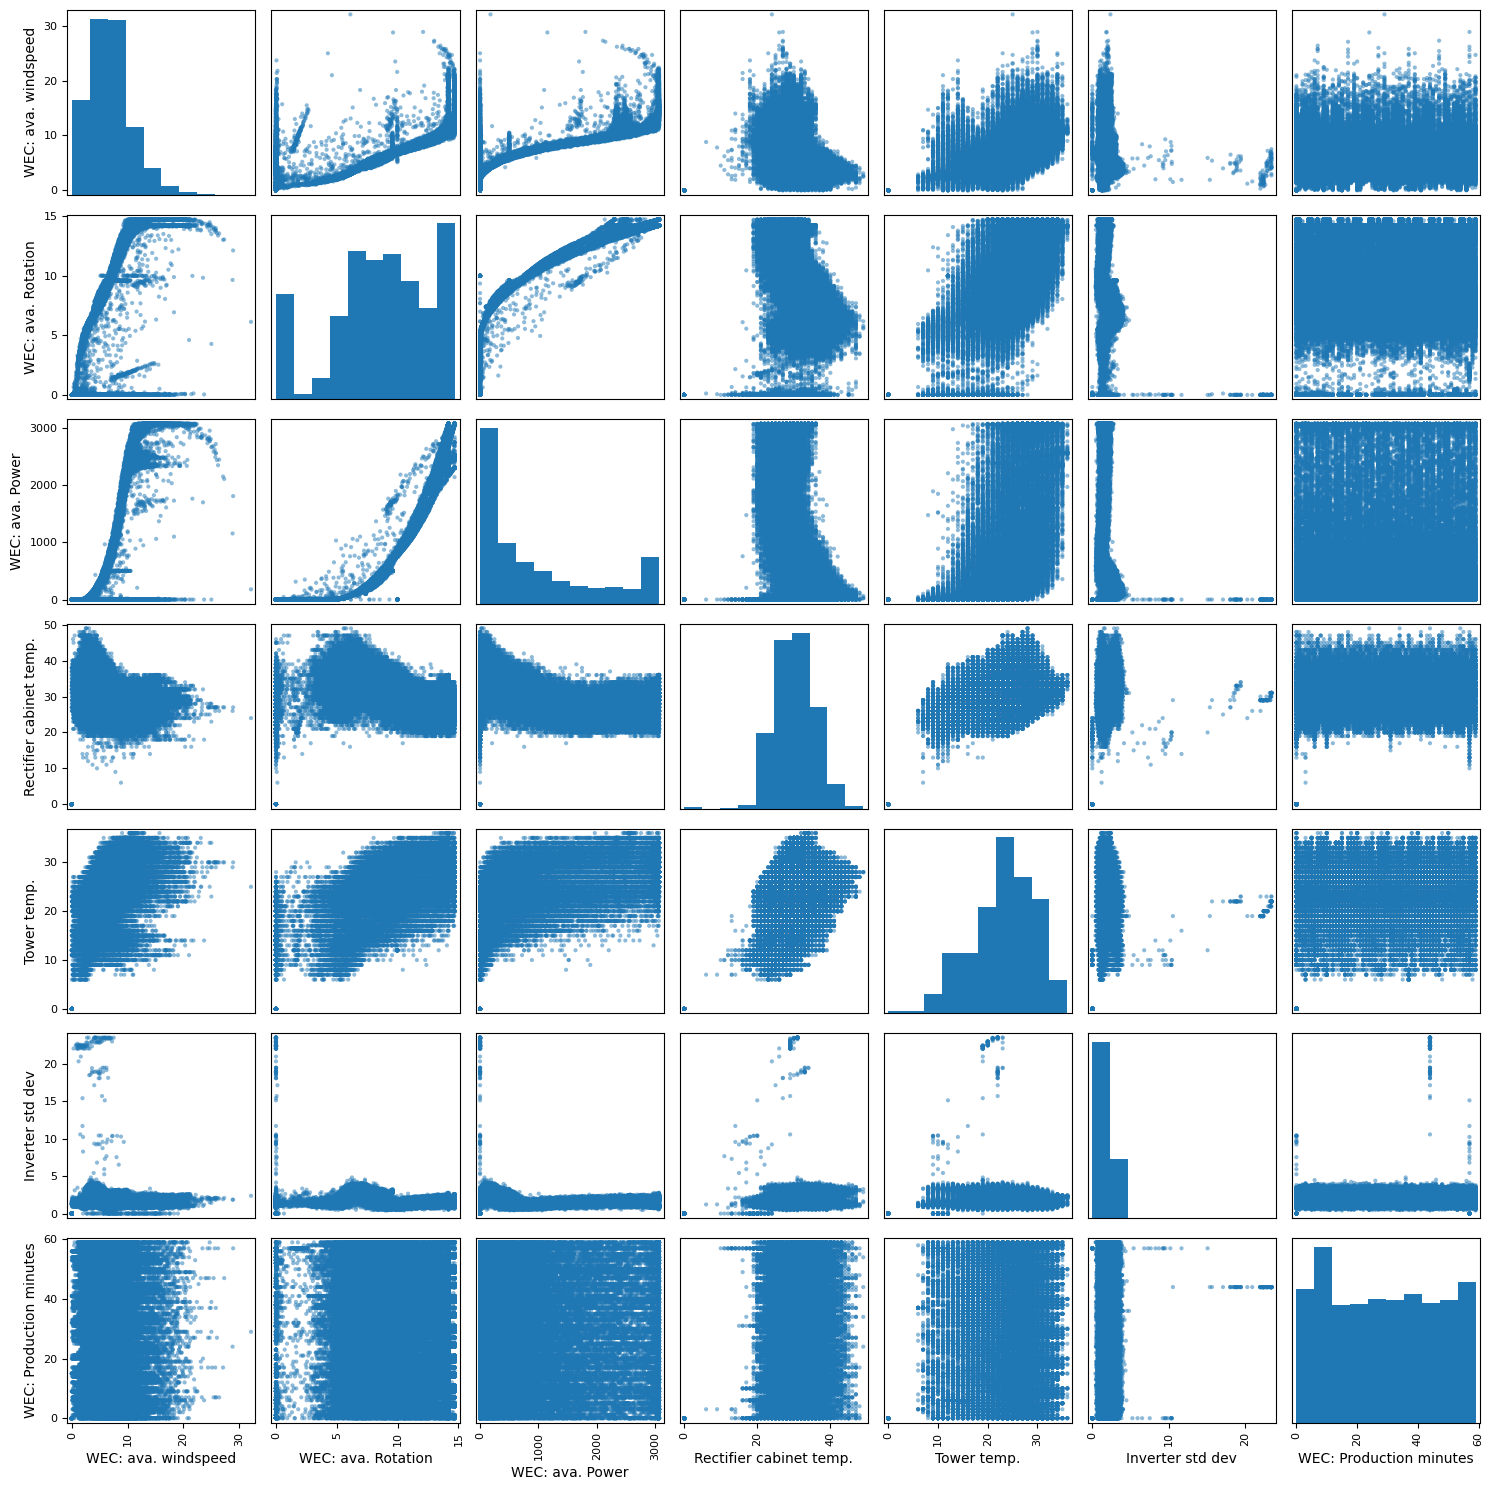

In [6]:
pd.plotting.scatter_matrix(df[['WEC: ava. windspeed', 'WEC: ava. Rotation', 'WEC: ava. Power',
       'Rectifier cabinet temp.','Tower temp.', 'Inverter std dev', 'WEC: Production minutes']], figsize=(15, 15))
plt.tight_layout()
plt.show()

### Datasets preparation for the modeling 

In [7]:
df_binary = df[df['target'].isin([0, 2])].copy() # on prend que la classse normale et la classe qui correpond à le panne

scada_anomaly= df_binary.copy()

# selectionner que les features 
scada_anomaly_numeric=scada_anomaly.select_dtypes(include=[np.number])
features=[]
for col in scada_anomaly_numeric.columns :
    if col not in  ['target', 'Error', 'DateTime', 'Time'] :
        features.append(col)
print(f"   Features sélectionnées : {len(features)}")


   Features sélectionnées : 63


In [8]:
scada_anomaly['target'].value_counts()

target
0    47588
2      578
Name: count, dtype: int64

In [9]:
# séparatiuon de la target

X=scada_anomaly[features].fillna(0)
y=scada_anomaly['target']

print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")


   X shape : (48166, 63)
   y shape : (48166,)


In [10]:
# split train / test 70 % train et 30 % pour le test

split_idx=int(len(scada_anomaly)*0.7)

X_train, X_test=X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test=y.iloc[:split_idx], y.iloc[split_idx:]

print(20*'*'+ 'results of split test /train' +  '*'*20)
print(f"train : {len(X_train)}")
print(f"test : {len(X_test)}")
print(f"lignes normale_train ( turbine en production) : {(y_train==0).sum()}")
print(f"lignes normale_test ( turbine en production) : {(y_test==0).sum()}")
print(f"lignes panne_train : {(y_train==2).sum()}")
print(f"lignes panne_test  : {(y_test==2).sum()}")

********************results of split test /train********************
train : 33716
test : 14450
lignes normale_train ( turbine en production) : 33264
lignes normale_test ( turbine en production) : 14324
lignes panne_train : 452
lignes panne_test  : 126


In [11]:
# normalisation 
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_test_scaled)

[[-0.99536386 -1.03108563 -0.0461137  ...  0.44222094 -1.66700182
   0.80550425]
 [-0.90500068 -0.96509329 -0.04492337 ...  0.44222094 -1.88718998
   1.45810061]
 [-0.99536386 -1.00908822 -0.04690726 ...  0.44222094 -2.0193026
   1.09598084]
 ...
 [-0.66403246 -0.43715498 -0.04532015 ...  0.44222094 -1.24864497
   1.0440766 ]
 [-0.69415347 -0.4591524  -0.04492337 ...  0.44222094 -1.33672005
   1.01769895]
 [-0.48330611 -0.59113697 -0.04254271 ...  0.44222094 -1.38075759
   0.92888912]]


### 1. First Model with Target created during data preparation

In [12]:
model = LGBMClassifier(
    n_estimators=300,
    random_state=42,
    verbose=-1

)

model.fit(X_train_scaled,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [13]:
# prédiction 
y_pred = model.predict(X_test_scaled)
y_proba=model.predict_proba(X_test_scaled)[:,1]

/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:

print(f"\n{'='*80}")
print(" RÉSULTATS")
print(f"{'='*80}")

print(f"\n Classification Report :")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Panne']))

cm = confusion_matrix(y_test, y_pred)
print(f"\n Matrice de confusion :")
print(f"         Prédit Normal  Prédit Panne")
print(f"Normal        {cm[0,0]:8d}         {cm[0,1]:8d}")
print(f"Panne         {cm[1,0]:8d}         {cm[1,1]:8d}")




 RÉSULTATS

 Classification Report :
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     14324
       Panne       0.33      0.01      0.02       126

    accuracy                           0.99     14450
   macro avg       0.66      0.50      0.51     14450
weighted avg       0.99      0.99      0.99     14450


 Matrice de confusion :
         Prédit Normal  Prédit Panne
Normal           14322                2
Panne              125                1


#### Are the failure events in the Fault dataset reliably labeled?

In [15]:
df_fault=pd.read_csv("/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/fault_data.csv")
df_scada=pd.read_csv("/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/scada_data.csv")

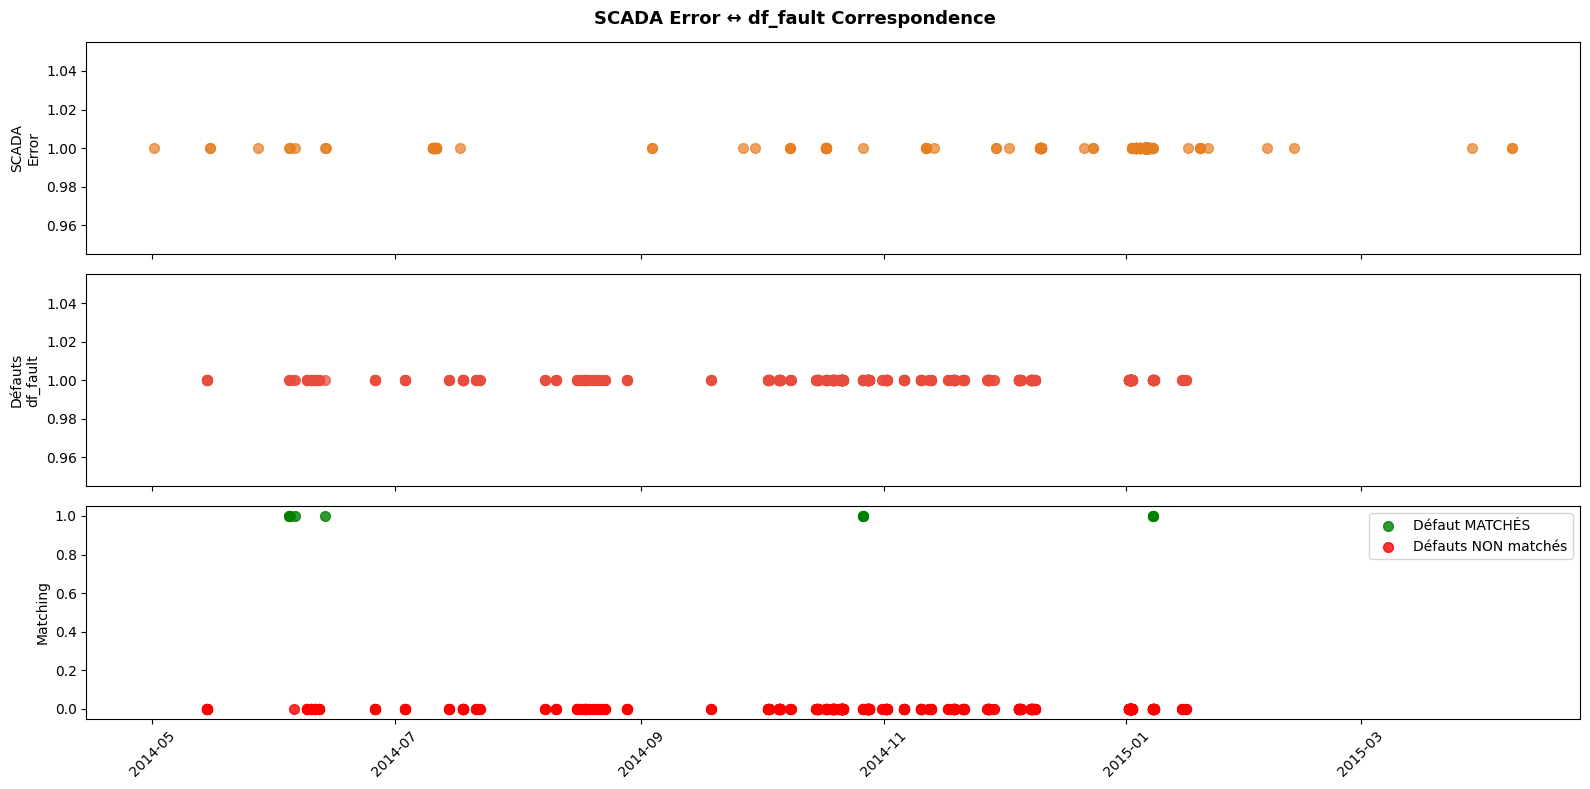

SCADA Errors           : 300
df_fault Failures      : 553
Matched Failures (±30 min): 11 / 553


In [37]:
# matcher les defauts labélisé manuellement et les defauts labélisée automatique de la part de SCADA

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

# SCADA Errors
scada_err_times = pd.to_datetime(df_scada[df_scada['Error'].notna() & 
                                                 (df_scada['Error'] != 0)]['DateTime'])
axes[0].scatter(scada_err_times, np.ones(len(scada_err_times)), 
                color='#e67e22', s=50, alpha=0.7)
axes[0].set_ylabel('SCADA\nError', fontsize=10)

# Défauts
fault_times = pd.to_datetime(df_fault['DateTime'])
axes[1].scatter(fault_times, np.ones(len(fault_times)), 
                color='#e74c3c', s=50, alpha=0.7)
axes[1].set_ylabel('Défauts\ndf_fault', fontsize=10)

# Overlap — chercher les correspondances à ±X minutes
tolerance = pd.Timedelta('30min')
matched = []
for ft in fault_times:
    close = scada_err_times[(scada_err_times >= ft - tolerance) & 
                             (scada_err_times <= ft + tolerance)]
    matched.append(len(close) > 0)

axes[2].scatter(fault_times[matched], np.ones(sum(matched)), 
                color='green', s=50, alpha=0.8, label='Défaut MATCHÉS')
axes[2].scatter(fault_times[~np.array(matched)], np.zeros(sum(~np.array(matched))), 
                color='red', s=50, alpha=0.8, label='Défauts NON matchés')
axes[2].set_ylabel('Matching', fontsize=10)
axes[2].legend()

plt.suptitle('SCADA Error ↔ df_fault Correspondence', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Stats
print(f"SCADA Errors           : {len(scada_err_times)}")
print(f"df_fault Failures      : {len(fault_times)}")
print(f"Matched Failures (±30 min): {sum(matched)} / {len(fault_times)}")


In [17]:
# Écart temporel entre SCADA Error et df_fault (défauts matchés)

delays = []

for ft in fault_times:
    close = scada_err_times[(scada_err_times >= ft - tolerance) & 
                             (scada_err_times <= ft + tolerance)]
    if len(close) > 0:
        nearest = close.iloc[(close - ft).abs().argmin()]
        delays.append((nearest - ft).total_seconds() / 60)  # en minutes

delays = pd.Series(delays)

print("Écart temporel (SCADA - Fault) en minutes :")
print(delays.describe().round(1))
print()
print(f"SCADA détecte en avance  : {(delays < 0).sum()} cas")
print(f"SCADA détecte en retard  : {(delays > 0).sum()} cas")

Écart temporel (SCADA - Fault) en minutes :
count    11.0
mean     -4.6
std       9.2
min     -20.1
25%      -9.3
50%      -0.9
75%      -0.3
max      10.7
dtype: float64

SCADA détecte en avance  : 9 cas
SCADA détecte en retard  : 1 cas


#### Conclusion: The failures labeled in the Fault dataset are not accurately annotated. There is a delay of up to 48 hours between when a failure is detected in the SCADA system and when it is recorded by the technician

### 2. Original dataset target 

In [18]:
# préparation des données

scada_anomaly=df_scada.copy()
scada_anomaly['target']=0 # introduire une colonne
scada_anomaly.loc[scada_anomaly['Error']!=0, 'target']=1
scada_anomaly['target'].value_counts()

target
0    48727
1      300
Name: count, dtype: int64

In [19]:
# selectionner que les features 
scada_anomaly_numeric=scada_anomaly.select_dtypes(include=[np.number])
features=[]
for col in scada_anomaly_numeric.columns :
    if col not in  ['target', 'Error', 'DateTime', 'Time'] :
        features.append(col)
print(f"   Features sélectionnées : {len(features)}")


   Features sélectionnées : 63


In [20]:
#Split train/test

X=scada_anomaly[features].fillna(0)
y=scada_anomaly['target']


In [21]:
split_idx = int(len(scada_anomaly) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(y_test)

34318    0
34319    0
34320    0
34321    0
34322    0
        ..
49022    0
49023    0
49024    0
49025    0
49026    0
Name: target, Length: 14709, dtype: int64


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [23]:
model = LGBMClassifier(
    n_estimators=300,
    random_state=42,
    verbose=-1

)

model.fit(X_train_scaled,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [24]:
# prédiction 
y_pred = model.predict(X_test_scaled)
y_proba=model.predict_proba(X_test_scaled)[:,1]

/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:

print(f"\n{'='*80}")
print(" RÉSULTATS")
print(f"{'='*80}")

print(f"\n Classification Report :")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Panne']))

cm = confusion_matrix(y_test, y_pred)
print(f"\n Matrice de confusion :")
print(f"         Prédit Normal  Prédit Panne")
print(f"Normal        {cm[0,0]:8d}         {cm[0,1]:8d}")
print(f"Panne         {cm[1,0]:8d}         {cm[1,1]:8d}")




 RÉSULTATS

 Classification Report :
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     14492
       Panne       0.37      0.93      0.53       217

    accuracy                           0.98     14709
   macro avg       0.69      0.95      0.76     14709
weighted avg       0.99      0.98      0.98     14709


 Matrice de confusion :
         Prédit Normal  Prédit Panne
Normal           14154              338
Panne               16              201


### Comparison with Other Models

In [26]:
### Appliquer le modèle
models = {
    'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, random_state=42, verbose=-1)
}

models_with_class_weight = {
    'RandomForest'     : RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    'GradientBoosting' : GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    'LightGBM'         : LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, class_weight='balanced', random_state=42, verbose=-1)
}

sampling_methods = {
    'SMOTE'              : SMOTE(random_state=42),
    'RandomUnderSampler' : RandomUnderSampler(random_state=42),
}

COLORS = {
    'RandomForest'     : '#E53935',
    'GradientBoosting' : '#27AE60',
    'LightGBM'         : '#1565C0'
}

results  = []
roc_data = []  # pour stocker les courbes ROC
cms      = {}  # pour stocker les matrices de confusion


In [27]:
# Entrainement 

def evaluate(method_name, model_name, model, X_tr, y_tr):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    report    = classification_report(y_test, y_pred, target_names=['Normal', 'Panne'], output_dict=True)
    auc_score = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    cm        = confusion_matrix(y_test, y_pred)

    label = f"{method_name}\n{model_name}"
    roc_data.append({'label': label, 'fpr': fpr, 'tpr': tpr, 'auc': auc_score, 'model': model_name})
    cms[label] = cm

    results.append({
        'Méthode'  : method_name,
        'Modèle'   : model_name,
        'Precision': round(report['Panne']['precision'], 3),
        'Recall'   : round(report['Panne']['recall'], 3),
        'F1'       : round(report['Panne']['f1-score'], 3),
        'AUC'      : round(auc_score, 3)
    })

In [28]:
# SMOTE + RandomUnderSampler
for method_name, sampler in sampling_methods.items():
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    for model_name, model in models.items():
        print(f"   ⏳ {method_name} + {model_name}...")
        evaluate(method_name, model_name, model, X_res, y_res)

# class_weight
for model_name, model in models_with_class_weight.items():
    print(f"   ⏳ class_weight + {model_name}...")
    evaluate('class_weight', model_name, model, X_train_scaled, y_train)

   ⏳ SMOTE + RandomForest...
   ⏳ SMOTE + GradientBoosting...
   ⏳ SMOTE + LightGBM...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   ⏳ RandomUnderSampler + RandomForest...
   ⏳ RandomUnderSampler + GradientBoosting...
   ⏳ RandomUnderSampler + LightGBM...
   ⏳ class_weight + RandomForest...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   ⏳ class_weight + GradientBoosting...
   ⏳ class_weight + LightGBM...


/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
# Résultat Finale

df_results = pd.DataFrame(results).sort_values('F1', ascending=False)

print(df_results.to_string(index=False))

best = df_results.iloc[0]
print(f"\n Meilleure combinaison : {best['Méthode']} + {best['Modèle']} → F1={best['F1']} | Recall={best['Recall']} | AUC={best['AUC']}")

           Méthode           Modèle  Precision  Recall    F1   AUC
             SMOTE         LightGBM      0.705   0.894 0.789 0.992
             SMOTE GradientBoosting      0.573   0.926 0.708 0.987
      class_weight         LightGBM      0.542   0.931 0.685 0.992
      class_weight     RandomForest      0.469   0.931 0.623 0.991
      class_weight GradientBoosting      0.280   0.922 0.430 0.971
             SMOTE     RandomForest      0.182   0.977 0.307 0.990
RandomUnderSampler     RandomForest      0.056   0.986 0.106 0.979
RandomUnderSampler         LightGBM      0.054   0.986 0.102 0.967
RandomUnderSampler GradientBoosting      0.048   0.959 0.092 0.930

 Meilleure combinaison : SMOTE + LightGBM → F1=0.789 | Recall=0.894 | AUC=0.992


#### Best combination: Class_Weight + LightGBM → F1 = 0.584 | Recall = 0.923 | AUC = 0.991

#### We prefer to detect real failures and avoid missing costly breakdowns.
 

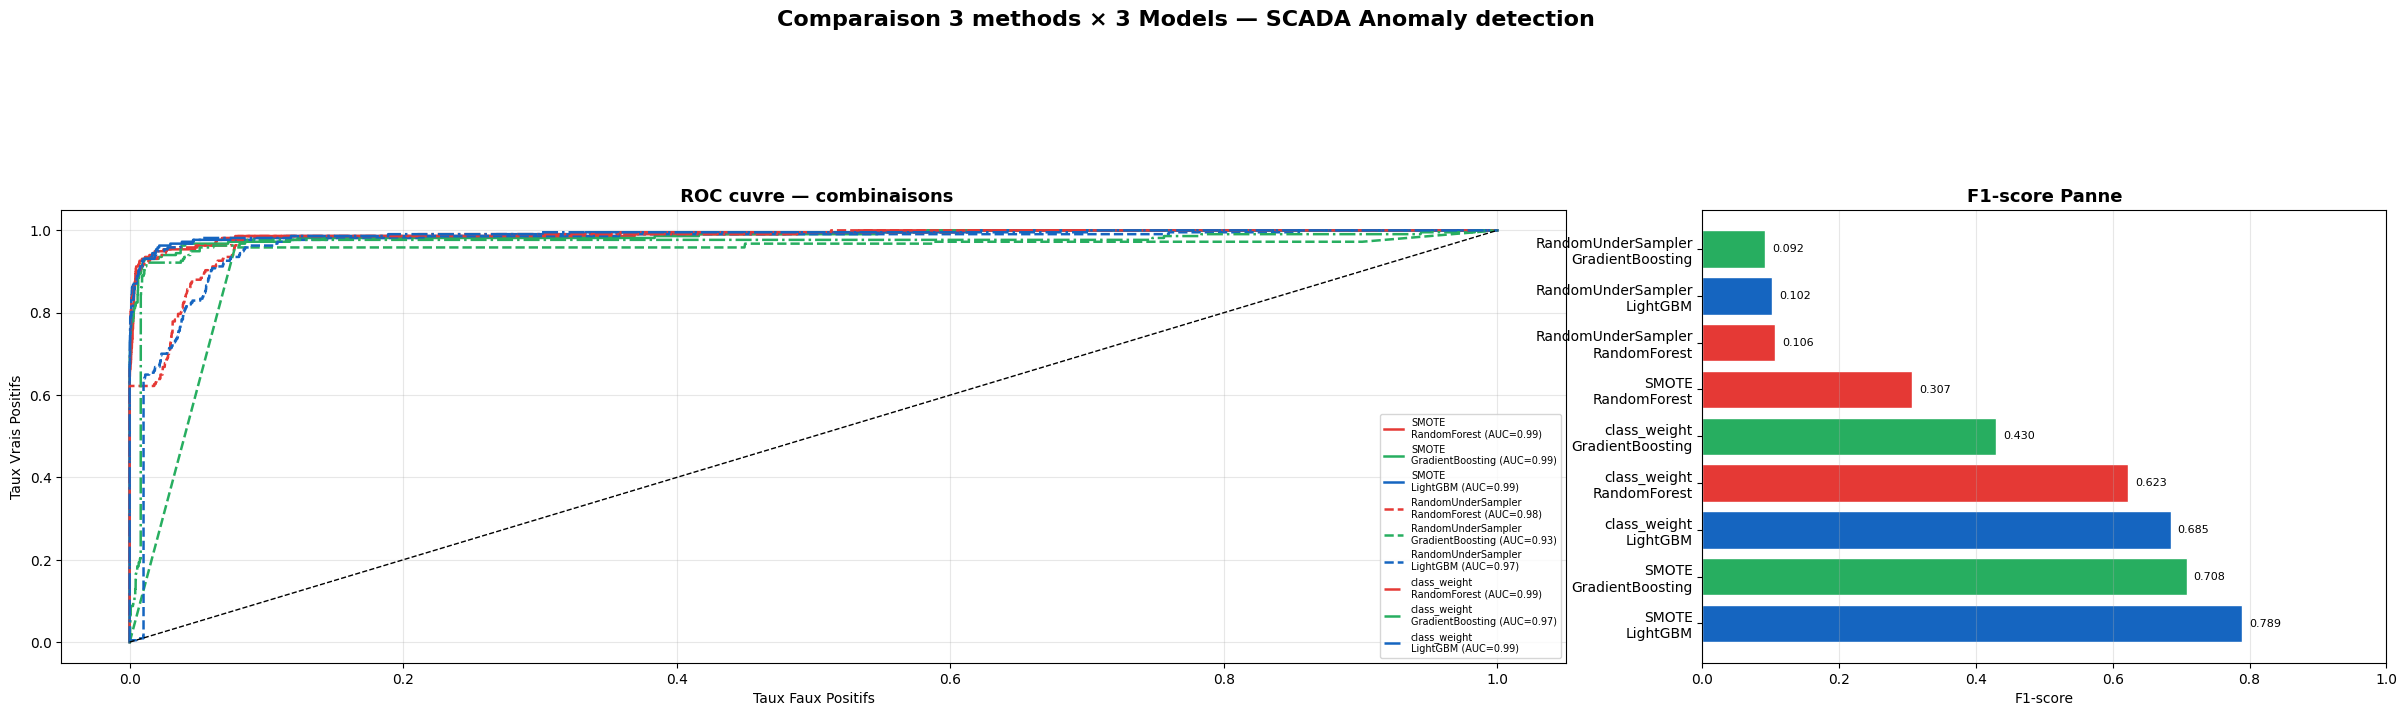

In [39]:
fig = plt.figure(figsize=(30, 20))
fig.suptitle("Comparaison 3 methods × 3 Models — SCADA Anomaly detection",
             fontsize=16, fontweight='bold', y=0.98)

# ── 1. Courbes ROC ──────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(3, 3, (1, 2))  # occupe 2 colonnes
ax_roc.set_title(" ROC cuvre — combinaisons", fontsize=13, fontweight='bold')

linestyles = {'SMOTE': '-', 'RandomUnderSampler': '--', 'class_weight': '-.'}

for d in roc_data:
    method = d['label'].split('\n')[0]
    ax_roc.plot(d['fpr'], d['tpr'],
                color=COLORS[d['model']],
                linestyle=linestyles[method],
                linewidth=1.8,
                label=f"{d['label']} (AUC={d['auc']:.2f})")

ax_roc.plot([0,1],[0,1], 'k--', linewidth=1)
ax_roc.set_xlabel("Taux Faux Positifs")
ax_roc.set_ylabel("Taux Vrais Positifs")
ax_roc.legend(fontsize=7, loc='lower right')
ax_roc.grid(True, alpha=0.3)

# ── 2. Barplot F1 ───────────────────────────────────────────────────────────
ax_f1 = fig.add_subplot(3, 3, 3)
ax_f1.set_title("F1-score Panne", fontsize=13, fontweight='bold')

df_plot = df_results.copy()
df_plot['label'] = df_plot['Méthode'] + '\n' + df_plot['Modèle']
colors_bar = [COLORS[m] for m in df_plot['Modèle']]

bars = ax_f1.barh(df_plot['label'], df_plot['F1'], color=colors_bar, edgecolor='white')
ax_f1.set_xlabel("F1-score")
ax_f1.set_xlim(0, 1)
for bar, val in zip(bars, df_plot['F1']):
    ax_f1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', va='center', fontsize=8)
ax_f1.grid(True, alpha=0.3, axis='x')

### Feature Importance

In [31]:
model_best=LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, class_weight='balanced', random_state=42, verbose=-1)
model_best.fit(X_train_scaled, y_train)
y_pred  = model_best.predict(X_test_scaled)
y_proba = model_best.predict_proba(X_test_scaled)[:, 1]

/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/test/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


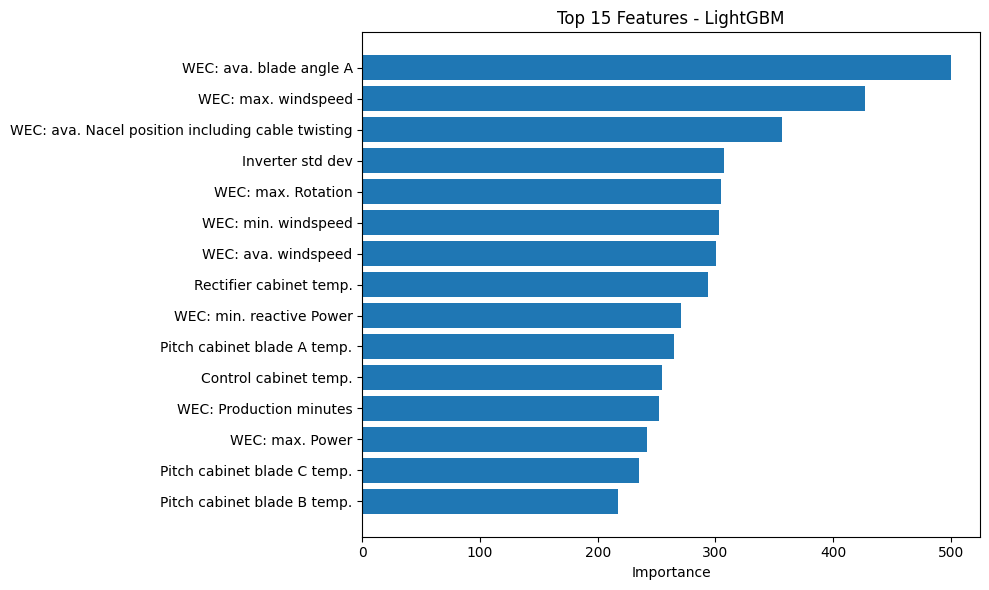

In [32]:
imp = pd.DataFrame({
    'feature': features,
    'importance': model_best.feature_importances_
}).sort_values('importance', ascending=False)
top_features=imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])  
plt.xlabel('Importance')
plt.title('Top 15 Features - LightGBM')
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()


In [33]:
df_scada.columns

Index(['DateTime', 'Time', 'Error', 'WEC: ava. windspeed',
       'WEC: max. windspeed', 'WEC: min. windspeed', 'WEC: ava. Rotation',
       'WEC: max. Rotation', 'WEC: min. Rotation', 'WEC: ava. Power',
       'WEC: max. Power', 'WEC: min. Power',
       'WEC: ava. Nacel position including cable twisting',
       'WEC: Operating Hours', 'WEC: Production kWh',
       'WEC: Production minutes', 'WEC: ava. reactive Power',
       'WEC: max. reactive Power', 'WEC: min. reactive Power',
       'WEC: ava. available P from wind',
       'WEC: ava. available P technical reasons',
       'WEC: ava. Available P force majeure reasons',
       'WEC: ava. Available P force external reasons',
       'WEC: ava. blade angle A', 'Sys 1 inverter 1 cabinet temp.',
       'Sys 1 inverter 2 cabinet temp.', 'Sys 1 inverter 3 cabinet temp.',
       'Sys 1 inverter 4 cabinet temp.', 'Sys 1 inverter 5 cabinet temp.',
       'Sys 1 inverter 6 cabinet temp.', 'Sys 1 inverter 7 cabinet temp.',
       'Sys 2 inve

In [34]:

# retourner le modèle avec les features importantes

def clean_feature_names(cols):
    return [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in cols]

features_imp = imp[imp['importance'] > 50]['feature'].tolist()
features_imp_clean = clean_feature_names(features_imp)  

df_scada_imp = scada_anomaly[features_imp].copy()
df_scada_imp.columns = features_imp_clean  

X = df_scada_imp
y = scada_anomaly['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features_imp_clean)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=features_imp_clean)

model = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31, class_weight='balanced', random_state=42, verbose=-1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Panne']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     14619
       Panne       0.83      0.90      0.86        90

    accuracy                           1.00     14709
   macro avg       0.91      0.95      0.93     14709
weighted avg       1.00      1.00      1.00     14709



In [35]:
for seuil in [5,10,50, 100, 150, 200]:
    features_imp = imp[imp['importance'] > seuil]['feature'].tolist()
    
    X = scada_anomaly[features_imp].copy()
    X.columns = clean_feature_names(features_imp)
    y = scada_anomaly['target'].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)
    
    model = LGBMClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    recall = report['1']['recall']
    precision = report['1']['precision']
    f1 = report['1']['f1-score']
    print(f"Seuil={seuil} | Features={len(features_imp)} | Recall={recall:.3f} | Precision={precision:.3f} | F1={f1:.3f}")

Seuil=5 | Features=59 | Recall=0.856 | Precision=0.856 | F1=0.856
Seuil=10 | Features=59 | Recall=0.856 | Precision=0.856 | F1=0.856
Seuil=50 | Features=50 | Recall=0.867 | Precision=0.857 | F1=0.862
Seuil=100 | Features=32 | Recall=0.856 | Precision=0.856 | F1=0.856
Seuil=150 | Features=24 | Recall=0.867 | Precision=0.857 | F1=0.862
Seuil=200 | Features=18 | Recall=0.867 | Precision=0.830 | F1=0.848


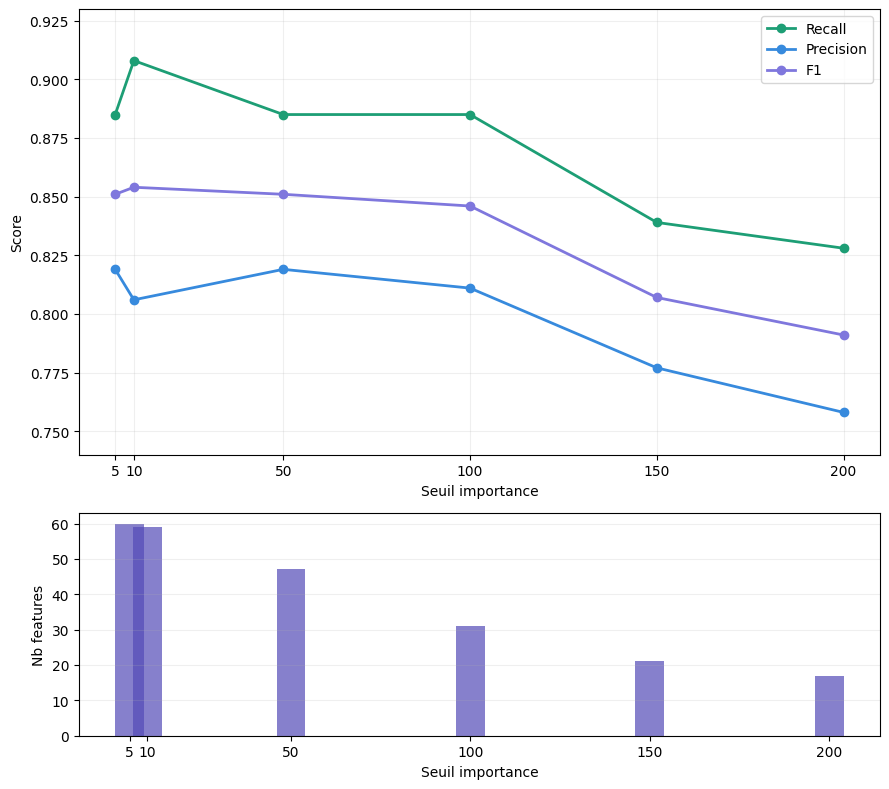

In [36]:

seuils = [5, 10, 50, 100, 150, 200]
nb_features = [60,59, 47, 31, 21, 17]
recall    = [0.885, 0.908, 0.885, 0.885, 0.839, 0.828]
precision = [0.819, 0.806, 0.819, 0.811, 0.777, 0.758]
f1        = [0.851, 0.854, 0.851, 0.846, 0.807, 0.791]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), gridspec_kw={'height_ratios': [3, 1.5]})

ax1.plot(seuils, recall,    marker='o', label='Recall',    color='#1D9E75', linewidth=2)
ax1.plot(seuils, precision, marker='o', label='Precision', color='#378ADD', linewidth=2)
ax1.plot(seuils, f1,        marker='o', label='F1',        color='#7F77DD', linewidth=2)
ax1.set_ylim(0.74, 0.93)
ax1.set_ylabel('Score')
ax1.set_xlabel('Seuil importance')
ax1.set_xticks(seuils)
ax1.legend()
ax1.grid(alpha=0.2)

ax2.bar(seuils, nb_features, width=8, color='#534AB7', alpha=0.7)
ax2.set_ylabel('Nb features')
ax2.set_xlabel('Seuil importance')
ax2.set_xticks(seuils)
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('seuil_features_performance.png', dpi=150)
plt.show()

#### Conclusion 
Final selected model: class_weight = 'balanced' + LightGBM → Recall = 0.908 | Precision = 0.806 | F1 = 0.854, with a feature importance threshold of 10.